In [14]:
import os
import sys
sys.path.append('JG_Wrapper')

current_path = os.getcwd()
print(current_path)

import numpy as np
import os
import ctypes
import time
from numpy.typing import NDArray
from typing import Tuple, Union
from numpy.ctypeslib import ndpointer
from wrapper_functions import *
import reverb as rev
import matplotlib.pyplot as plt

omega = 2*np.pi/(3600*24) ## in per s
chord_lat = 49.3 ## chord zenith declination (deg)


/project/6004619/dcs01/JG_CHORD_Imaging_Wrapper


In [15]:
def compute_simulation_parameters(fwhm_arcmin, samples_per_beam, imsize, delta_tau=480, im_center=(0, chord_lat)):
    """
    Compute simulation parameters for a radio telescope.

    Parameters:
    - fwhm_arcmin (float): Synthesized beam FWHM in arcminutes.
    - samples_per_beam (int): Number of pixels per beam (for both spatial and time sampling).
    - imsize (int): Number of image pixels per side.
    - delta_tau (float): Time step in seconds (default is 10s, does not impact final resolution).

    Returns:
    - dict containing:
        - delta_tau (float): Time step in seconds. #set to 10s and does not impact final resolution
        - time_samples (int): Number of time samples (symmetrically covering image).
        - fwhm_arcmin (float): Input FWHM.
        - cellsize_deg (float): Computed pixel size in degrees.
        - imsize (int): Image size (pixels per side).
        - initial_phi_offset_rad (float): Half-image angular width in radians.
        - dphi (float): Degrees of RA per time step.
    """

    # Constants
    OMEGA_DEG = 360 * np.cos(np.deg2rad(im_center[1])) / (3600 * 24 - 240)  # degrees/s
    # OMEGA_DEG = 360 / (3600 * 24) 

    fwhm_deg = fwhm_arcmin / 60  # Convert FWHM from arcmin to degrees

    # Compute cell size to match spatial beam sampling
    cellsize_deg = fwhm_deg / samples_per_beam  # arcmin -> deg
    extent_deg = cellsize_deg * imsize  # total image extent in degrees

    # Compute number of time samples needed to sweep across the full image width
    dphi = OMEGA_DEG * delta_tau  # degrees of RA per time step
    time_samples = int(np.ceil(extent_deg*3 / dphi))  # Cover image width plus buffer on both sides
    # Compute initial phi offset in degrees
    initial_phi_offset_deg = dphi * (time_samples-1) / 2  # Half-image angular width in degrees

    return {
        "delta_tau": delta_tau,
        "time_samples": time_samples,
        "fwhm_arcmin": fwhm_arcmin,
        "cellsize_deg": cellsize_deg,
        "imsize": imsize,
        "initial_phi_offset_deg": initial_phi_offset_deg,
        "dphi": dphi
    }


In [32]:
# Initialize result lists
theoretical_noise_stds = []
computed_noise_rms = []
dirtymap_peaks = []
dtau_list = []
N_times_list = []

# Static variables that don't change across iterations
imcenter = (0, 49)  # (RA, dec) of the centre of the image. This also sets the WCS
M = 22 ## how many antennae in NS direction
N = 24 ## how many antennae in EW direction
L1 = 8.5 ## antenna spacing delta in NS direction (in m)
L2 = 6.3 ## antenna spacing delta in EW direction (in m)
chord_lat = 49.3 ## chord zenith declination (deg)
ant_diam = 6 ## antenna diameter (in m)
survey_dec = 49  # Set's CHORD zenith declination
nu1 = 1420e6  # first channel frequency (Hz)
channel_width = 0.185e6  # channel width (Hz)
nchannels = 1  # number of channels
nu2 = nu1 + channel_width * nchannels  # last channel frequency (Hz)
dnu = (nu2-nu1)/nchannels  # (computed for you)
eta = 1  # antenna power collection efficiency
SEFD = 6000  # per antenna system equivalent flux density (in Jy)

frequencies = np.linspace(nu1, nu2, nchannels)
wavelengths = 3e8/frequencies

u_new = np.array([rev.u(imcenter[0],imcenter[1])]) ## u coordinates of new source, in rad
F_new = np.array([0.001]) ## Flux density [Jy] snapshot at 1.4GHz
s_new = np.array([0]) ## spectral index. Flux density for this source will go like frequency^{s}
spectra = rev.get_spectra(frequencies,F_new,s_new)
source_us = u_new

imsize_list = [5, 15, 25, 50, 100, 150, 200, 300, 500, 700]  # image sizes to test

for imsize in imsize_list:
    print(f"Processing image size: {imsize}")  # Progress indicator
    
    # Variables that change with imsize
    sim_params = compute_simulation_parameters(
        fwhm_arcmin=3.8,
        samples_per_beam=5,
        imsize=imsize,
        delta_tau=30,
        im_center=imcenter)

    cellsize = sim_params['cellsize_deg']
    dphi = sim_params['dphi']
    dtau = sim_params['delta_tau']
    centre_phi_RA_deg = imcenter[0]
    N_times = sim_params['time_samples']
    initial_phi_offset = sim_params['initial_phi_offset_deg']

    # Generate image coordinates (depends on imsize and cellsize)
    u, w = rev.gen_image_u(imcenter, cellsize, imsize)
    del(w)

    # CHORD setup (depends on dtau and N_times)
    chord_thetas = np.asarray([np.deg2rad(90-survey_dec)], dtype=ctypes.c_float)
    cp = chordParams(thetas=unpackArraytoStruct(chord_thetas),
                    centre_phi=np.deg2rad(centre_phi_RA_deg),
                    initial_phi_offset=np.deg2rad(initial_phi_offset),
                    m1=M, m2=N, L1=L1, L2=L2, CHORD_zenith_dec=chord_lat, D=ant_diam,
                    delta_tau=dtau, time_samples=N_times)
    
    dirtymap = dirtymap_simulator_wrapper (u.astype(ctypes.c_float), wavelengths.astype(ctypes.c_float), source_us, spectra, 1e-9, cp)
    dirtymap = dirtymap.reshape(imsize,imsize,len(frequencies))

    dirtymap /= M**2
    dirtymap /= N**2 ## for normalization

    # Generate noise and beam (depends on imsize)
    noise = np.zeros((imsize, imsize, len(frequencies)))
    for i in range(len(frequencies)):
        noise[:,:,i] = rev.make_some_noise(M, N, L1, L2, chord_lat, survey_dec, N_times, 
                                         dnu, dtau, SEFD, eta, frequencies[i], imsize, 
                                         cellsize, ant_diam, applybeam=False)

    A_beam, B_beam = rev.recover_net_beam(u, centre_phi_RA_deg, initial_phi_offset, dphi, 
                                        N_times, frequencies, survey_dec, antenna_diam=ant_diam)

    # Apply beam normalization
    for i in range(len(frequencies)):
        noise[:,:,i] *= B_beam[:,:,i]

    for i in range(len(frequencies)):
        maxx = np.max(A_beam[:,:,i])
        A_beam[:,:,i] /= maxx
        noise[:,:,i] /= maxx
        dirtymap[:,:,i] /= maxx

    # Calculate noise statistics
    theoretical_noise_std = 1000*SEFD / np.sqrt(2 * (M * N*(M * N - 1)/2) * dnu * dtau * N_times)
    noise_std = np.std(noise[A_beam > 0.95]) * 1e3

    # Store results
    theoretical_noise_stds.append(theoretical_noise_std)
    computed_noise_rms.append(noise_std)
    dirtymap_peaks.append(np.max(dirtymap)*1000)
    dtau_list.append(dtau)
    N_times_list.append(N_times)

    # Clean up memory
    del noise, A_beam, B_beam, u

Processing image size: 5
Device count: 1
Processing image size: 15
Device count: 1
Processing image size: 25
Device count: 1
Processing image size: 50
Device count: 1
Processing image size: 100
Device count: 1
Processing image size: 150
Device count: 1
Processing image size: 200
Device count: 1
Processing image size: 300
Device count: 1
Processing image size: 500
Device count: 1
Processing image size: 700
Device count: 1


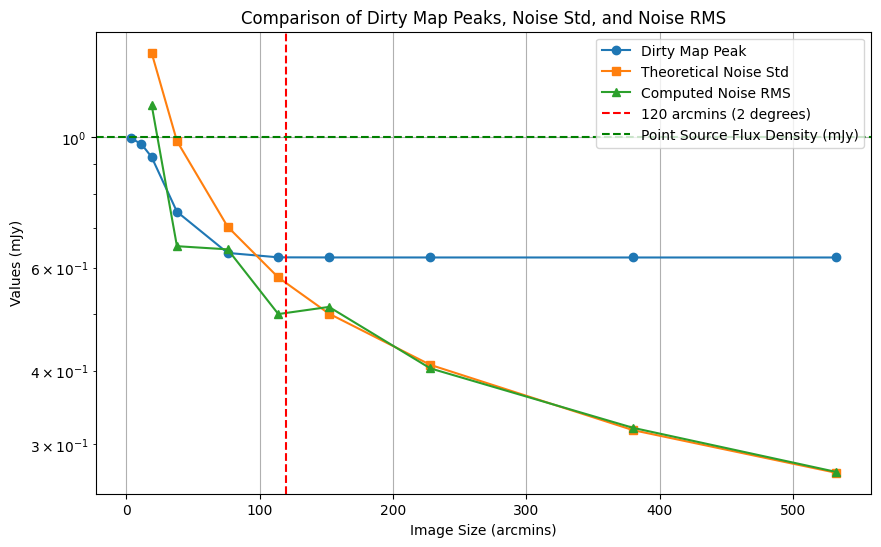

In [ ]:
plt.figure(figsize=(10, 6))
imsize_list = np.array(imsize_list)
imsize_arcmins = imsize_list * cellsize * 60

# Plot dirtymap_peaks
plt.plot(imsize_arcmins, dirtymap_peaks, label='Dirty Map Peak', marker='o')

# Plot theoretical_noise_stds
plt.plot(imsize_arcmins[imsize_list>20], np.array(theoretical_noise_stds)[imsize_list>20], label='Theoretical Noise Std', marker='s')

# Plot computed_noise_rms
plt.plot(imsize_arcmins[imsize_list>20], np.array(computed_noise_rms)[imsize_list>20], label='Computed Noise Std', marker='^')

plt.axvline(x=120, color='r', linestyle='--', label='120 arcmins (2 degrees)')
plt.axhline(y=F_new[0]*1000, color='g', linestyle='--', label='Point Source Flux Density (mJy)')

# Add labels, legend, and title
plt.xlabel('Image Size (arcmins)')
plt.ylabel('Values (mJy)')
plt.title('Comparison of Dirty Map Peaks, Noise Std, and Noise Std')
plt.legend()
plt.grid(True)
plt.yscale('log')  # Use logarithmic scale for better visibility of differences

# Show the plot
plt.show()